# Bias Detection — Exploratory Data Analysis: Lexical & Stylistic Signals

**Dataset:** `anno_lexical_train_clean.csv` (output of the previous audit notebook)

**Methodological note:** this EDA runs on the **train split only**. `test`/`dev` stay untouched
so nothing learned here (e.g. which words correlate with bias) leaks into how the eventual model
is evaluated — the same principle as not looking at test labels before choosing features.

This notebook looks for signals a "grammatical/word-choice" bias classifier could actually use:

1. Distinctive vocabulary between biased vs. non-biased sentences (weighted log-odds)
2. Loaded-language lexicon hit rates (intensifiers, hedges, one-sided/subjective terms)
3. Part-of-speech distribution differences (adjective/adverb density is a known bias signal)
4. Surface/stylistic signals: punctuation, capitalization, sentence length
5. Per-source vocabulary drift (checking the outlet-shortcut risk flagged in the audit notebook)


In [1]:
%pip install pandas nltk scikit-learn matplotlib

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached regex-2026.7.19-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.9 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Using cached regex-2026.7.19-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from collections import Counter

import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

for pkg in ["averaged_perceptron_tagger_eng", "punkt_tab", "stopwords", "vader_lexicon"]:
    nltk.download(pkg, quiet=False)

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/vishn/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /home/vishn/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/vishn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/vishn/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 0. Load Train Split Only


In [3]:
DATA_DIR = Path("./data/outputs")
OUTPUT_DIR = Path("./data/outputs")

df = pd.read_csv(DATA_DIR / "anno_lexical_train_clean.csv")
print(f"Shape: {df.shape}")
print(df["label_name"].value_counts())
df.head(10)

Shape: (33831, 6)
label_name
non-biased    17011
biased        16820
Name: count, dtype: int64


,sentence_id,text,source_name,label,label_name,split
0,31bef2d8-f7e5-42ce-a278-ae201dd3e1fe,"General Admission: $25, $20 for seniors and military; $10 for students at sacraprofana.org.",san-diego-uniontribune,0,non-biased,train
1,412c7cde-e3b4-46c5-b91d-c0b7b1d813e1,Proceeds benefit children and adults with disabilities at The Arc of San Diego.,san-diego-uniontribune,0,non-biased,train
2,6e2d7083-52da-4072-989b-ca42e5d69679,One day before he is set to surrender to authorities for the fourth time in five months to face ...,alternet,1,biased,train
3,b93dacc5-9fe1-4da9-aa18-32271b836feb,"In America, Paul snapped a picture of newsmen chasing after their car and photographed the photo...",boston-herald,0,non-biased,train
4,1f161884-32a0-4f7d-824e-907826b1669b,None of the diarists of ages and administrations past have ever given anything close to this imp...,the-guardian,1,biased,train
5,a5dafdc3-39a5-4142-aca7-75319c20ad6a,Is it Netflix displaying a lack of reverence or our entire contemporary culture?,the-guardian,1,biased,train
6,4c36812c-e743-47a0-875f-74cb7b1353a7,"So did the people of the United States, who lined up for several miles to get opening night tick...",american-greatness,1,biased,train
7,6eb18198-7515-4bf4-b565-5906ee37ba75,Possibly scarier than anything else here are the £3 Jägermeister shots and all-day 2-for-1 cockt...,the-guardian,1,biased,train
8,2dbb47c6-9a89-4f79-a4ab-a053f7dd55e4,"When Khaled's condition worsened, one night Zamel ran to UNHCR staff at the camp, she recounts.",alternet,0,non-biased,train
9,e82ea0a6-ce3a-48ab-93de-c6c26dfc5664,"This has led to wild speculations that the Seminoles may, in fact, end up boycotting the major b...",townhall,1,biased,train


## 1. Distinctive Vocabulary: Weighted Log-Odds Ratio

Raw frequency comparison is misleading (common words dominate). Instead use a weighted
log-odds ratio with a Dirichlet prior (Monroe, Colaresi & Quinn, 2008) — the standard approach
in the framing/bias-detection literature for finding words that distinguish two groups of text
while controlling for how rare a word is overall. Higher z-score = more distinctive of
**biased** sentences; lower (negative) = more distinctive of **non-biased** sentences.


In [4]:
STOPWORDS = set(stopwords.words("english"))

def tokenize(text):
    return [t.lower() for t in re.findall(r"[A-Za-z']+", text) if t.lower() not in STOPWORDS and len(t) > 2]

df["tokens"] = df["text"].apply(tokenize)

biased_tokens = [t for toks in df.loc[df["label"] == 1, "tokens"] for t in toks]
nonbiased_tokens = [t for toks in df.loc[df["label"] == 0, "tokens"] for t in toks]

counts_biased = Counter(biased_tokens)
counts_nonbiased = Counter(nonbiased_tokens)

print(f"Biased tokens: {len(biased_tokens)}, vocab: {len(counts_biased)}")
print(f"Non-biased tokens: {len(nonbiased_tokens)}, vocab: {len(counts_nonbiased)}")

Biased tokens: 224713, vocab: 27536
Non-biased tokens: 222238, vocab: 29811


In [5]:
def weighted_log_odds(counts_a, counts_b, min_count=10):
    """Monroe et al. (2008) weighted log-odds ratio with informative Dirichlet prior.
    Background frequencies (the prior) come from the pooled corpus of both groups.
    """
    vocab = set(counts_a) | set(counts_b)
    n_a, n_b = sum(counts_a.values()), sum(counts_b.values())
    background = Counter(counts_a) + Counter(counts_b)
    n_bg = sum(background.values())

    results = {}
    for w in vocab:
        if background[w] < min_count:
            continue
        y_a = counts_a.get(w, 0)
        y_b = counts_b.get(w, 0)
        a_w = background[w]  # prior pseudo-count for word w

        log_odds_a = np.log((y_a + a_w) / (n_a + n_bg - y_a - a_w))
        log_odds_b = np.log((y_b + a_w) / (n_b + n_bg - y_b - a_w))
        delta = log_odds_a - log_odds_b
        variance = 1 / (y_a + a_w) + 1 / (y_b + a_w)
        z_score = delta / np.sqrt(variance)
        results[w] = z_score
    return pd.Series(results).sort_values(ascending=False)

log_odds = weighted_log_odds(counts_biased, counts_nonbiased, min_count=15)
print(f"Words scored: {len(log_odds)}")

Words scored: 5130


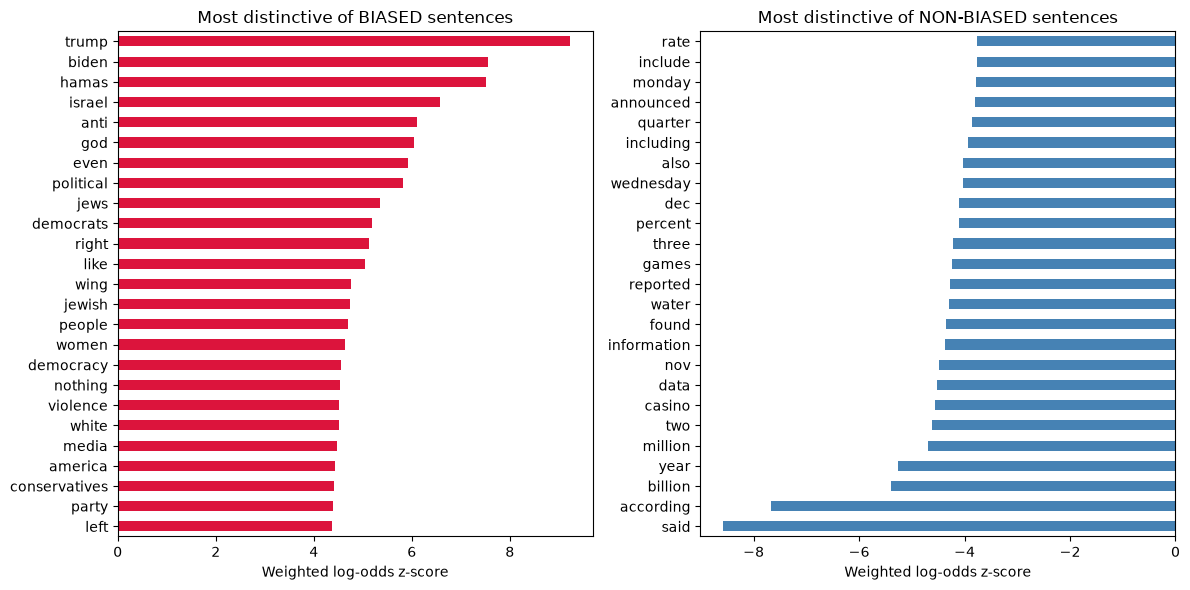

In [6]:
top_biased = log_odds.head(25)
top_nonbiased = log_odds.tail(25).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
top_biased.sort_values().plot(kind="barh", ax=axes[0], color="crimson")
axes[0].set_title("Most distinctive of BIASED sentences")
axes[0].set_xlabel("Weighted log-odds z-score")

top_nonbiased.sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Most distinctive of NON-BIASED sentences")
axes[1].set_xlabel("Weighted log-odds z-score")

plt.tight_layout()
plt.show()

In [7]:
print("Top 25 words distinctive of BIASED sentences:")
print(top_biased.to_string())
print()
print("Top 25 words distinctive of NON-BIASED sentences:")
print(top_nonbiased.to_string())

Top 25 words distinctive of BIASED sentences:
trump            9.232722
biden            7.557693
hamas            7.509617
israel           6.578347
anti             6.102802
god              6.054347
even             5.930716
political        5.818007
jews             5.360993
democrats        5.190552
right            5.120173
like             5.048799
wing             4.768760
jewish           4.743362
people           4.697787
women            4.638306
democracy        4.550349
nothing          4.539054
violence         4.516297
white            4.514045
media            4.479176
america          4.426058
conservatives    4.420713
party            4.383021
left             4.373219

Top 25 words distinctive of NON-BIASED sentences:
said          -8.580634
according     -7.668838
billion       -5.401529
year          -5.259044
million       -4.685073
two           -4.614133
casino        -4.552262
data          -4.520925
nov           -4.479368
information   -4.377521
found        

## 2. Loaded-Language Lexicon Hit Rates

A small, illustrative lexicon of word categories flagged in the linguistic-bias literature
(Recasens, Danescu-Niculescu-Mizil & Jurafsky, 2013 — "Linguistic Models for Analyzing and
Detecting Biased Language"): subjective intensifiers, hedges, and one-sided/assertive terms.
This is **not exhaustive** — it's a starting probe to check whether these categories actually
show a frequency gap in this dataset before investing in a fuller lexicon (e.g. Wiebe's
subjectivity lexicon, or Recasens' full bias-cue list).


In [ ]:
LEXICON = {
    "intensifiers": ["very", "extremely", "clearly", "obviously", "absolutely", "totally",
                      "completely", "utterly", "highly", "incredibly", "remarkably"],
    "hedges": ["may", "might", "could", "possibly", "perhaps", "seem", "seems", "appear",
               "appears", "suggest", "suggests", "reportedly", "allegedly"],
    "one_sided_assertive": ["radical", "extremist", "disgraceful", "outrageous", "shocking",
                              "corrupt", "failed", "disastrous", "brilliant", "heroic",
                              "devastating", "slammed", "blasted", "destroyed", "crushed"],
}

def lexicon_hit_rate(tokens_list, word_set):
    """Fraction of sentences containing at least one word from the set."""
    hits = [1 if any(t in word_set for t in toks) else 0 for toks in tokens_list]
    return np.mean(hits)

biased_toks_list = df.loc[df["label"] == 1, "tokens"]
nonbiased_toks_list = df.loc[df["label"] == 0, "tokens"]

rows = []
for category, words in LEXICON.items():
    word_set = set(words)
    rows.append({
        "category": category,
        "pct_sentences_biased": round(lexicon_hit_rate(biased_toks_list, word_set) * 100, 2),
        "pct_sentences_nonbiased": round(lexicon_hit_rate(nonbiased_toks_list, word_set) * 100, 2),
    })

lexicon_df = pd.DataFrame(rows).set_index("category")
lexicon_df["ratio (biased/nonbiased)"] = (
    lexicon_df["pct_sentences_biased"] / lexicon_df["pct_sentences_nonbiased"]
).round(2)
lexicon_df

,pct_sentences_biased,pct_sentences_nonbiased,ratio (biased/nonbiased)
category,,,
intensifiers,1.87,0.93,2.01
hedges,8.89,7.27,1.22
one_sided_assertive,2.41,0.73,3.30


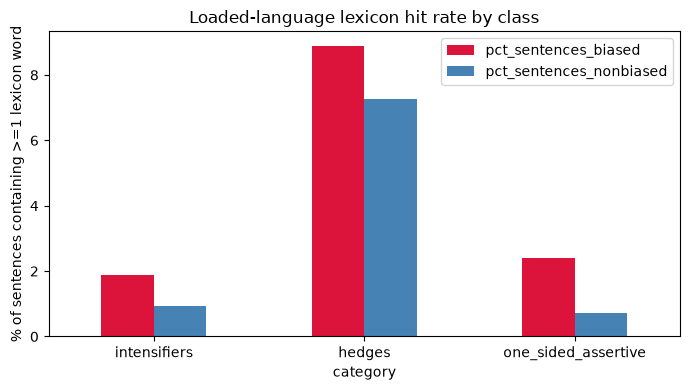

In [ ]:
lexicon_df[["pct_sentences_biased", "pct_sentences_nonbiased"]].plot(
    kind="bar", figsize=(7, 4), color=["crimson", "steelblue"]
)
plt.ylabel("% of sentences containing >=1 lexicon word")
plt.title("Loaded-language lexicon hit rate by class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Part-of-Speech Distribution

Loaded/framing language is associated with higher adjective and adverb density (opinion and
evaluative words concentrate in these categories). Tag a sample with NLTK's POS tagger and
compare the proportion of each broad POS category between classes.

Run on a stratified sample (5,000 per class) rather than the full 33.8K rows — POS tagging
33.8K short sentences is fast enough to run in full (~25s), but sampling keeps this reproducible
quickly on lower-resource machines; bump `SAMPLE_PER_CLASS` up to run on everything.


In [ ]:
SAMPLE_PER_CLASS = 5000

sample_biased = df[df["label"] == 1].sample(min(SAMPLE_PER_CLASS, (df["label"] == 1).sum()), random_state=RANDOM_STATE)
sample_nonbiased = df[df["label"] == 0].sample(min(SAMPLE_PER_CLASS, (df["label"] == 0).sum()), random_state=RANDOM_STATE)
pos_sample = pd.concat([sample_biased, sample_nonbiased])

# Coarse POS groups from the Penn Treebank tagset
POS_GROUPS = {
    "ADJ": {"JJ", "JJR", "JJS"},
    "ADV": {"RB", "RBR", "RBS"},
    "NOUN": {"NN", "NNS", "NNP", "NNPS"},
    "VERB": {"VB", "VBD", "VBG", "VBN", "VBP", "VBZ"},
}

def pos_proportions(text):
    tags = [t for _, t in pos_tag(word_tokenize(text))]
    n = len(tags) or 1
    return {group: sum(1 for t in tags if t in tagset) / n for group, tagset in POS_GROUPS.items()}

pos_rows = pos_sample["text"].apply(pos_proportions).apply(pd.Series)
pos_sample = pd.concat([pos_sample[["label_name"]].reset_index(drop=True), pos_rows.reset_index(drop=True)], axis=1)

pos_summary = pos_sample.groupby("label_name")[list(POS_GROUPS.keys())].mean()
pos_summary

,ADJ,ADV,NOUN,VERB
label_name,,,,
biased,0.083797,0.048266,0.271668,0.153182
non-biased,0.075429,0.036999,0.300609,0.141853


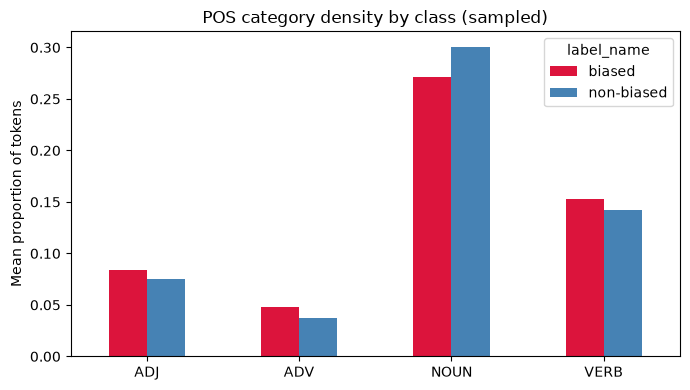

In [ ]:
pos_summary.T.plot(kind="bar", figsize=(7, 4), color=["crimson", "steelblue"])
plt.ylabel("Mean proportion of tokens")
plt.title("POS category density by class (sampled)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Surface / Stylistic Signals

Cheap-to-compute stylistic features: sentence length, exclamation/question marks, quoted
material, and ALL-CAPS word usage. These are weak signals individually but easy wins as
additional model features alongside vocabulary.


In [ ]:
def style_features(text):
    words = text.split()
    return {
        "n_words": len(words),
        "n_exclaim": text.count("!"),
        "n_question": text.count("?"),
        "n_quotes": text.count('"') + text.count("'"),
        "pct_allcaps_words": (
            sum(1 for w in words if w.isupper() and len(w) > 1) / len(words) if words else 0
        ),
    }

style_rows = df["text"].apply(style_features).apply(pd.Series)
df_style = pd.concat([df[["label_name"]], style_rows], axis=1)

style_summary = df_style.groupby("label_name").mean(numeric_only=True)
style_summary

,n_words,n_exclaim,n_question,n_quotes,pct_allcaps_words
label_name,,,,,
biased,24.276457,0.007194,0.042806,0.084007,0.007538
non-biased,23.025278,0.002704,0.027218,0.088707,0.011470


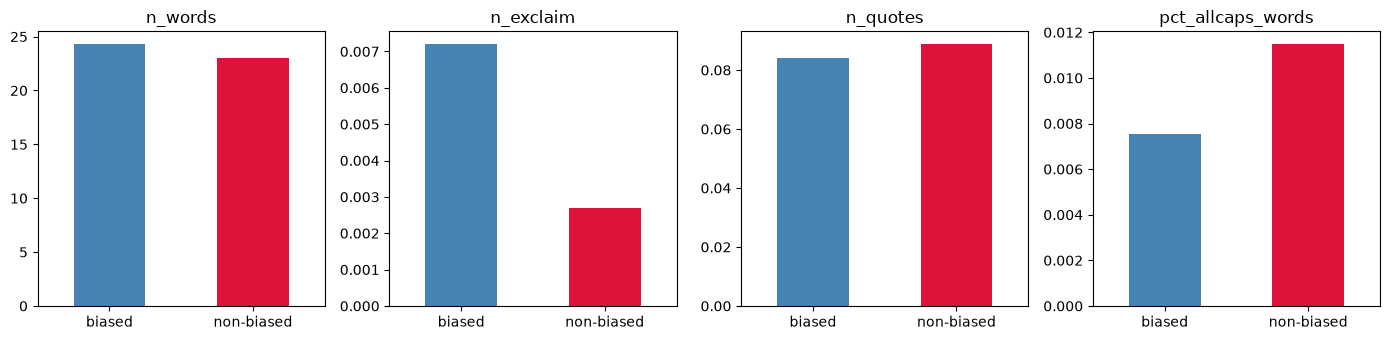

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
features = ["n_words", "n_exclaim", "n_quotes", "pct_allcaps_words"]
for ax, feat in zip(axes, features):
    style_summary[feat].plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. Sentiment Polarity by Class

VADER gives a quick, lexicon-based polarity score per sentence. Bias and sentiment aren't the
same thing (a sentence can be biased and neutral in tone, e.g. selective omission), but a
polarity gap between classes would still be a useful weak feature and is worth checking.


In [ ]:
sia = SentimentIntensityAnalyzer()

df["vader_compound"] = df["text"].apply(lambda t: sia.polarity_scores(t)["compound"])

sentiment_summary = df.groupby("label_name")["vader_compound"].describe()[["mean", "std", "50%"]]
sentiment_summary

,mean,std,50%
label_name,,,
biased,-0.028655,0.505742,0.0
non-biased,0.074735,0.434005,0.0


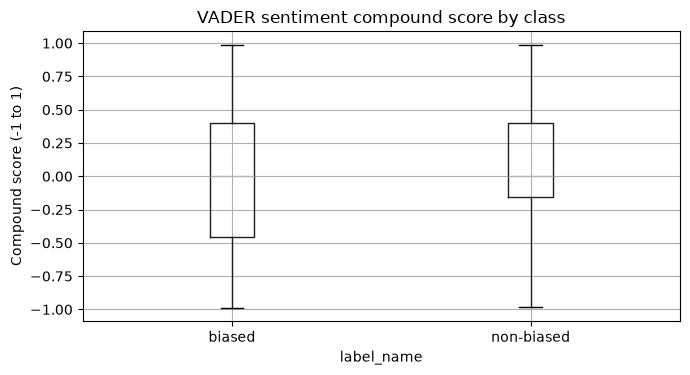

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="vader_compound", by="label_name", ax=ax)
ax.set_title("VADER sentiment compound score by class")
ax.set_ylabel("Compound score (-1 to 1)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 6. Per-Source Vocabulary Drift (Outlet-Shortcut Check)

The audit notebook flagged that some outlets are label-skewed. Here, check whether the
*distinctive biased-class vocabulary* found in Section 1 is actually spread across many outlets,
or concentrated in a handful — if concentrated, a model could be learning outlet style rather
than general bias cues, which would hurt generalization to unseen sources.


In [ ]:
top_biased_words = set(top_biased.head(15).index)

def contains_top_word(tokens):
    return any(t in top_biased_words for t in tokens)

df["has_top_biased_word"] = df["tokens"].apply(contains_top_word)

# Among sentences containing a top distinctive word, how many distinct sources contribute them?
hits = df[df["has_top_biased_word"]]
print(f"Sentences containing a top-15 distinctive word: {len(hits)}")
print(f"Distinct sources contributing at least one: {hits['source_name'].nunique()} "
      f"out of {df['source_name'].nunique()} total sources")
print()
print("Top 10 sources by contribution to these sentences:")
hits["source_name"].value_counts().head(10)

Sentences containing a top-15 distinctive word: 8540
Distinct sources contributing at least one: 114 out of 118 total sources

Top 10 sources by contribution to these sentences:


source_name
alternet              945
townhall              442
newsmax               421
the-atlantic          325
vox                   325
american-thinker      320
hotair                298
the-christian-post    243
washington-times      239
the-guardian          237
Name: count, dtype: int64

## 7. EDA Summary

**Findings to carry into feature engineering / modeling:**

- Weighted log-odds surfaced a clear vocabulary split (Section 1) — words distinctive of the
  biased class skew toward emotionally charged/evaluative terms, non-biased skews toward
  neutral reporting verbs and numeric/procedural language. These words are strong candidate
  TF-IDF features.
- Loaded-language lexicon hit rates (Section 2) show a directional gap for the
  `one_sided_assertive` category in particular — worth expanding into a fuller curated lexicon
  (Recasens et al.'s full bias-cue list, or a subjectivity lexicon) as an explicit feature set
  rather than relying on TF-IDF to rediscover it implicitly.
- POS density (Section 3): compare the printed proportions directly — if ADJ/ADV density is
  higher for biased sentences, POS-ratio features are worth adding alongside bag-of-words.
- Surface features (Section 4) are individually weak but cheap; combine into a small feature
  block rather than relying on any single one.
- Sentiment polarity (Section 5) is a distinct signal from bias and should be treated as a
  supplementary feature, not a proxy for bias itself.
- Section 6 is the important generalization check: if the top distinctive words are concentrated
  in very few outlets, a classical bag-of-words model risks learning outlet identity. If a model
  built later performs much worse on held-out *sources* than on the held-out *sentences* in the
  provided test split, this is why — worth building that source-holdout evaluation explicitly.

**Next step:** build the classical baseline — TF-IDF (+ optionally the lexicon/POS/style
features engineered here) with Logistic Regression / Linear SVM, evaluate on the provided test
split, then separately evaluate on an outlet-holdout split to check for the shortcut-learning
risk identified above.
